## STAT 206 Final Project Report - Group 2: Exploring Olympic Medal Patterns by Country, Gender, and Economic Factors


### Kimberly Calderon, Alicia Garcia, and Anthony Lara

 March 19th, 2026 @ 5:00 PM


## Introduction and Analytical Goals:

Throughout the decades, the popularity of the Summer and Winter Olympic Games has experienced a notable growth in viewship and fans due for a variety of reasons such as interest in the different host nations, the variety of sport events present at both the Summer and Winter Games, and also the popularity of new or returning olympic athletes. With the recent 2026 Milano Cortina Winter Olympic Games having concluded, our group decided to explore a dataset that will offer us insight on past Olympic games as recent as 2014, and explore all variables associated with medal winning coutnries and atheltes.

The dataset that our group will be using for analysis is the “Olympic Games Dataset” from Kaggle. This includes three CSV files: “Countries”, “Winter”, and “Summer”. These detail GDP, population, athlete information, medal totals, type of Olympic event, and distinction between the Summer Games and Winter Games. The dataset covers events from 1896, when the Olympics began, to 2014, which gives us a large amount of data to visualize trends.

With these variables, we aim to explore whether GDP is an influential factor in determining which countries have the most medals. Additionally, we would like to explore if gender plays an influential role in high medal counts. Is there a difference in how many female Olympians win medals in the Winter Olympics compared to the Summer Olympics? Overall, is there a difference in the medals awarded to male Olympians versus female Olympians in both the Winter and Summer Olympics? Does one gender dominate over another? With these questions, we would also like to take into account the years and consider if there is a correlation or pattern in which countries or genders triumphed in medal counts over the years.



## Initial Data Exploration and Cleaning:

To begin our data analysis and visualizations, we first needed to remove any missing values from our datasets to then be able to conduct our preliminary explorations. These prelinary explorations are what allow us to see in detail what variables we are working with and which ones we believe will work best with our established analytical goals.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
countries = pd.read_csv("CountriesSD.csv")
summer = pd.read_csv("SummerSD.csv")
winter = pd.read_csv("WinterSD.csv")

In [3]:
countries.info()
summer.info()
winter.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      201 non-null    int64  
 1   Country         201 non-null    object 
 2   Code            201 non-null    object 
 3   Population      196 non-null    float64
 4   GDP per Capita  176 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 8.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31165 entries, 0 to 31164
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  31165 non-null  int64 
 1   Year        31165 non-null  int64 
 2   City        31165 non-null  object
 3   Sport       31165 non-null  object
 4   Discipline  31165 non-null  object
 5   Athlete     31165 non-null  object
 6   Code        31161 non-null  object
 7   Gender      31165 non-null  object
 8   Event

In [4]:
clean_countries = countries.dropna()
clean_countries

,Unnamed: 0,Country,Code,Population,GDP per Capita
0,0,Afghanistan,AFG,32526562.0,594.323081
1,1,Albania,ALB,2889167.0,3945.217582
2,2,Algeria,ALG,39666519.0,4206.031232
5,5,Angola,ANG,25021974.0,4101.472152
6,6,Antigua and Barbuda,ANT,91818.0,13714.731962
...,...,...,...,...,...
194,194,Vanuatu,VAN,264652.0,2805.314644
196,196,Vietnam,VIE,91703800.0,2111.138024
198,198,Yemen,YEM,26832215.0,1406.291651
199,199,Zambia,ZAM,16211767.0,1304.879014


In [5]:
clean_summer = summer.dropna()
clean_summer

,Unnamed: 0,Year,City,Sport,Discipline,Athlete,Code,Gender,Event,Medal,Country
0,0,1896,Athens,Aquatics,Swimming,Alfred Hajos,HUN,Men,100M Freestyle,Gold,Hungary
1,1,1896,Athens,Aquatics,Swimming,Otto Herschmann,AUT,Men,100M Freestyle,Silver,Austria
2,2,1896,Athens,Aquatics,Swimming,Dimitrios Drivas,GRE,Men,100M Freestyle For Sailors,Bronze,Greece
3,3,1896,Athens,Aquatics,Swimming,Ioannis Malokinis,GRE,Men,100M Freestyle For Sailors,Gold,Greece
4,4,1896,Athens,Aquatics,Swimming,Spiridon Chasapis,GRE,Men,100M Freestyle For Sailors,Silver,Greece
...,...,...,...,...,...,...,...,...,...,...,...
31160,31160,2012,London,Wrestling,Wrestling Freestyle,Damian Janikowski,POL,Men,Wg 84 KG,Bronze,Poland
31161,31161,2012,London,Wrestling,Wrestling Freestyle,Ghasem Gholamreza Rezaei,IRI,Men,Wg 96 KG,Gold,Iran
31162,31162,2012,London,Wrestling,Wrestling Freestyle,Rustam Totrov,RUS,Men,Wg 96 KG,Silver,Russia
31163,31163,2012,London,Wrestling,Wrestling Freestyle,Artur Aleksanyan,ARM,Men,Wg 96 KG,Bronze,Armenia


In [6]:
clean_winter = winter.dropna()
clean_winter

,Unnamed: 0,Year,City,Sport,Discipline,Athlete,Country,Gender,Event,Medal
0,0,1924,Chamonix,Biathlon,Biathlon,"BERTHET, G.",FRA,Men,Military Patrol,Bronze
1,1,1924,Chamonix,Biathlon,Biathlon,"MANDRILLON, C.",FRA,Men,Military Patrol,Bronze
2,2,1924,Chamonix,Biathlon,Biathlon,"MANDRILLON, Maurice",FRA,Men,Military Patrol,Bronze
3,3,1924,Chamonix,Biathlon,Biathlon,"VANDELLE, André",FRA,Men,Military Patrol,Bronze
4,4,1924,Chamonix,Biathlon,Biathlon,"AUFDENBLATTEN, Adolf",SUI,Men,Military Patrol,Gold
...,...,...,...,...,...,...,...,...,...,...
5765,5765,2014,Sochi,Skiing,Snowboard,"JONES, Jenny",GBR,Women,Slopestyle,Bronze
5766,5766,2014,Sochi,Skiing,Snowboard,"ANDERSON, Jamie",USA,Women,Slopestyle,Gold
5767,5767,2014,Sochi,Skiing,Snowboard,"MALTAIS, Dominique",CAN,Women,Snowboard Cross,Silver
5768,5768,2014,Sochi,Skiing,Snowboard,"SAMKOVA, Eva",CZE,Women,Snowboard Cross,Gold


In [7]:
medal_count_summer = (clean_summer.groupby("Country").size().sort_values(ascending = False).head(10))
medal_count_summer

Country
United States     4585
United Kingdom    1720
France            1396
Germany           1305
Italy             1296
Australia         1189
Hungary           1079
Sweden            1044
Netherlands        851
China              807
dtype: int64

In [8]:
Summer_Games_by_Year = clean_summer.sort_values(by='Year', ascending=False)
Summer_Games_by_Year

,Unnamed: 0,Year,City,Sport,Discipline,Athlete,Code,Gender,Event,Medal,Country
31164,31164,2012,London,Wrestling,Wrestling Freestyle,Jimmy Lidberg,SWE,Men,Wg 96 KG,Bronze,Sweden
29872,29872,2012,London,Boxing,Boxing,Shiming Zou,CHN,Men,46 - 49KG,Gold,China
29860,29860,2012,London,Basketball,Basketball,Laura Hodges,AUS,Women,Basketball,Bronze,Australia
29861,29861,2012,London,Basketball,Basketball,Lauren Jackson,AUS,Women,Basketball,Bronze,Australia
29862,29862,2012,London,Basketball,Basketball,Rachel Jarry,AUS,Women,Basketball,Bronze,Australia
...,...,...,...,...,...,...,...,...,...,...,...
97,97,1896,Athens,Gymnastics,Artistic G.,Dimitrios Loundras,GRE,Men,"Team, Parallel Bars",Bronze,Greece
96,96,1896,Athens,Gymnastics,Artistic G.,Phillippos Karvelas,GRE,Men,"Team, Parallel Bars",Bronze,Greece
95,95,1896,Athens,Gymnastics,Artistic G.,Ioannis Chrysaphis,GRE,Men,"Team, Parallel Bars",Bronze,Greece
94,94,1896,Athens,Gymnastics,Artistic G.,Hermann Weingärtner,GER,Men,"Team, Horizontal Bar",Gold,Germany


In [9]:
Winter_Games_by_Year = clean_winter.sort_values(by='Year', ascending=False)
Winter_Games_by_Year

,Unnamed: 0,Year,City,Sport,Discipline,Athlete,Country,Gender,Event,Medal
5769,5769,2014,Sochi,Skiing,Snowboard,"TRESPEUCH, Chloe",FRA,Women,Snowboard Cross,Bronze
5358,5358,2014,Sochi,Ice Hockey,Ice Hockey,"IRWIN, Haley",CAN,Women,Ice Hockey,Gold
5365,5365,2014,Sochi,Ice Hockey,Ice Hockey,"OUELLETTE, Caroline",CAN,Women,Ice Hockey,Gold
5364,5364,2014,Sochi,Ice Hockey,Ice Hockey,"MIKKELSON, Meaghan",CAN,Women,Ice Hockey,Gold
5363,5363,2014,Sochi,Ice Hockey,Ice Hockey,"LAROCQUE, Jocelyne",CAN,Women,Ice Hockey,Gold
...,...,...,...,...,...,...,...,...,...,...
84,84,1924,Chamonix,Skating,Figure skating,"BRUNET, Andrée",FRA,Women,Pairs,Bronze
85,85,1924,Chamonix,Skating,Figure skating,"BRUNET, Pierre",FRA,Men,Pairs,Bronze
86,86,1924,Chamonix,Skating,Figure skating,"BERGER, Alfred",AUT,Men,Pairs,Gold
87,87,1924,Chamonix,Skating,Figure skating,"ENGELMANN, Helene",AUT,Women,Pairs,Gold


## Statistical Test Exploring the Relationship Between Countries' GDP and Olympic Medals

To answer the question of whether or not a country's GDP per Capita had an affect on how many medals they won, we designed a statistical test for the summer and winter games, separately. Using a one sided t test, our group first analyzed the distribution of GDP per Capita among all available countries. Then, we split countries into two groups, a high GDP and low GDP group, using the 50% threshold of the data. The test compares the mean medal count in the high GDP group and the low GDP group, at the 0.05 level. These steps and hypotheses are displayed below.


### Summer Games Analysis

In [10]:
# joining the clean version of summer to clean version of countries - one to many
join_sum_countries = clean_summer.merge(clean_countries, on="Country", how="left")

# taking out unnecesary / repeat colums
join_sum_countries = join_sum_countries.drop(columns=["Unnamed: 0_x", "Unnamed: 0_y", "Code_y"])

In [11]:
join_sum_countries["GDP per Capita"].describe()

count     25142.000000
mean      36819.832226
std       19545.022998
min         277.068309
25%       17118.504200
50%       41313.313995
75%       56115.718426
max      101449.968168
Name: GDP per Capita, dtype: float64

<Axes: >

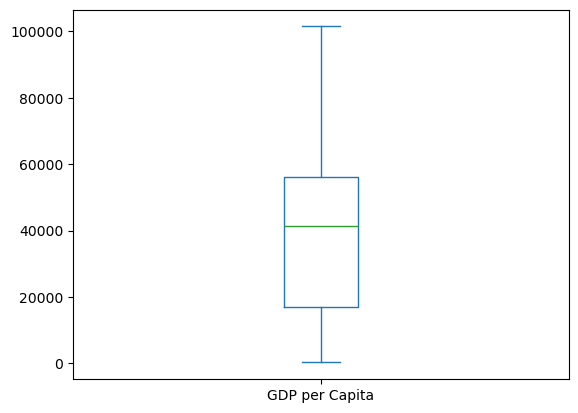

In [12]:
# visualize the distribution of GDP per Capita
join_sum_countries["GDP per Capita"].plot(kind="box")

In [13]:
# split joined data into upper half gdp and lower half gdp
high_GDP_summer = join_sum_countries[join_sum_countries["GDP per Capita"] >= 41313.313995]
low_GDP_summer = join_sum_countries[join_sum_countries["GDP per Capita"] < 41313.313995]

### Null & Alternative Hypothesis
$H_0: \mu_{high GDP} \leq \mu_{low GDP}$  
$H_a: \mu_{high GDP} > \mu_{low GDP}$

In [14]:
# Making correct table for high GDP
medal_count_high_S = high_GDP_summer[high_GDP_summer["Medal"].notna()]
medal_count_high_S = medal_count_high_S.groupby("Country")["Medal"].count().reset_index()
medal_count_high_S.rename(columns={"Medal": "Total_Medals"}, inplace=True)

# Table for low GDP to perform statistical testing
medal_count_low_S = low_GDP_summer[low_GDP_summer["Medal"].notna()]
medal_count_low_S = medal_count_low_S.groupby("Country")["Medal"].count().reset_index()
medal_count_low_S.rename(columns={"Medal": "Total_Medals"}, inplace=True)

In [15]:
from scipy.stats import ttest_ind

# Summer Test
t_stat, p_value_two_sided = ttest_ind(
    medal_count_high_S["Total_Medals"],
    medal_count_low_S["Total_Medals"],
    equal_var=False
)

# Convert to one-sided because we are trying to determine if high GDP medal count is higher
if t_stat > 0:
    p_value_one_sided = p_value_two_sided / 2
else:
    p_value_one_sided = 1

print("t-statistic:", t_stat)
print("one-sided p-value:", p_value_one_sided)

t-statistic: 2.1529907068386867
one-sided p-value: 0.02328403144047401


The results above show a p-value of 0.02. Because this is lower than 0.05, we can reject the null hypothesis that the mean medal counts of higher GDP countries are lower or equal to those of lower GDP countries. With this conclusion for the Summer Olympic Games, our group sees GDP per capita as a possible reason for the amount of medals a country wins at the Summer Olympics. We would suggest further research of the question and use other forms of regression to conclude.

### Winter Games Analysis

In [16]:
# joining the clean version of winter to clean version of countries - one to many
join_win_countries = clean_winter.merge(clean_countries, left_on="Country", right_on="Code", how="left")

In [17]:
join_win_countries["GDP per Capita"].describe()

count      4815.000000
mean      45811.946690
std       18374.658506
min        2114.954716
25%       41313.313995
50%       43248.529909
75%       56115.718426
max      101449.968168
Name: GDP per Capita, dtype: float64

<Axes: >

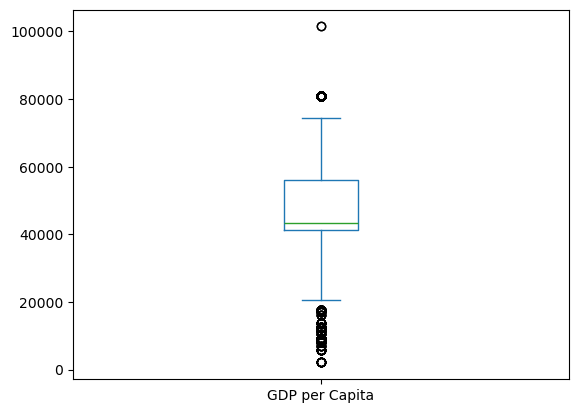

In [18]:
# visualize the distribution of GDP per Capita
join_win_countries["GDP per Capita"].plot(kind="box")

In [19]:
# split joined data into upper half gdp and lower half gdp
high_GDP_winter = join_win_countries[join_win_countries["GDP per Capita"] >= 43248.529909]
low_GDP_winter = join_win_countries[join_win_countries["GDP per Capita"] < 43248.529909]

In [20]:
# Making correct table for high GDP
medal_count_high_W = high_GDP_winter[high_GDP_winter["Medal"].notna()]
medal_count_high_W = medal_count_high_W.groupby("Country_y")["Medal"].count().reset_index()
medal_count_high_W.rename(columns={"Medal": "Total_Medals"}, inplace=True)

# Table for low GDP to perform statistical testing
medal_count_low_W = low_GDP_winter[low_GDP_winter["Medal"].notna()]
medal_count_low_W = medal_count_low_W.groupby("Country_y")["Medal"].count().reset_index()
medal_count_low_W.rename(columns={"Medal": "Total_Medals"}, inplace=True)

In [21]:
# Winter Test
t_stat, p_value_two_sided = ttest_ind(
    medal_count_high_W["Total_Medals"],
    medal_count_low_W["Total_Medals"],
    equal_var=False
)

# Convert to one-sided because we are trying to determine if high GDP medal count is higher
if t_stat > 0:
    p_value_one_sided = p_value_two_sided / 2
else:
    p_value_one_sided = 1

print("t-statistic:", t_stat)
print("one-sided p-value:", p_value_one_sided)

t-statistic: 2.4588226995573366
one-sided p-value: 0.014874242050492264


The p-value that is reported is ~0.01. Like the Summer Games, we can also reject the null hypothesis for the Winter Games. Since the p-value is even smaller in the Winter Games, we can be more confident of the accuracy of the test. This finding is important to understand because of how it relates to accessibility of sports. If athletes in certain countries have more access to equipment, training, and facilities, we can continue to expect results that depict countries that are financially stronger winning the most.

## EDA of Total Medal Distribution of the Top 10 Countries (Summer vs Winter)

In [22]:
# Summer
medal_count_summer = (clean_summer.groupby("Country").size().sort_values(ascending = False).head(10))
medal_count_summer

Country
United States     4585
United Kingdom    1720
France            1396
Germany           1305
Italy             1296
Australia         1189
Hungary           1079
Sweden            1044
Netherlands        851
China              807
dtype: int64

In [23]:
# Winter
medal_count_winter = (clean_winter.groupby("Country").size().sort_values(ascending = False).head(10))
medal_count_winter

Country
USA    653
CAN    625
NOR    457
URS    440
FIN    434
SWE    433
GER    360
SUI    285
AUT    280
RUS    263
dtype: int64

Text(0.5, 1.0, 'Top 10 Countries with Most Olympic Medals (Winter)')

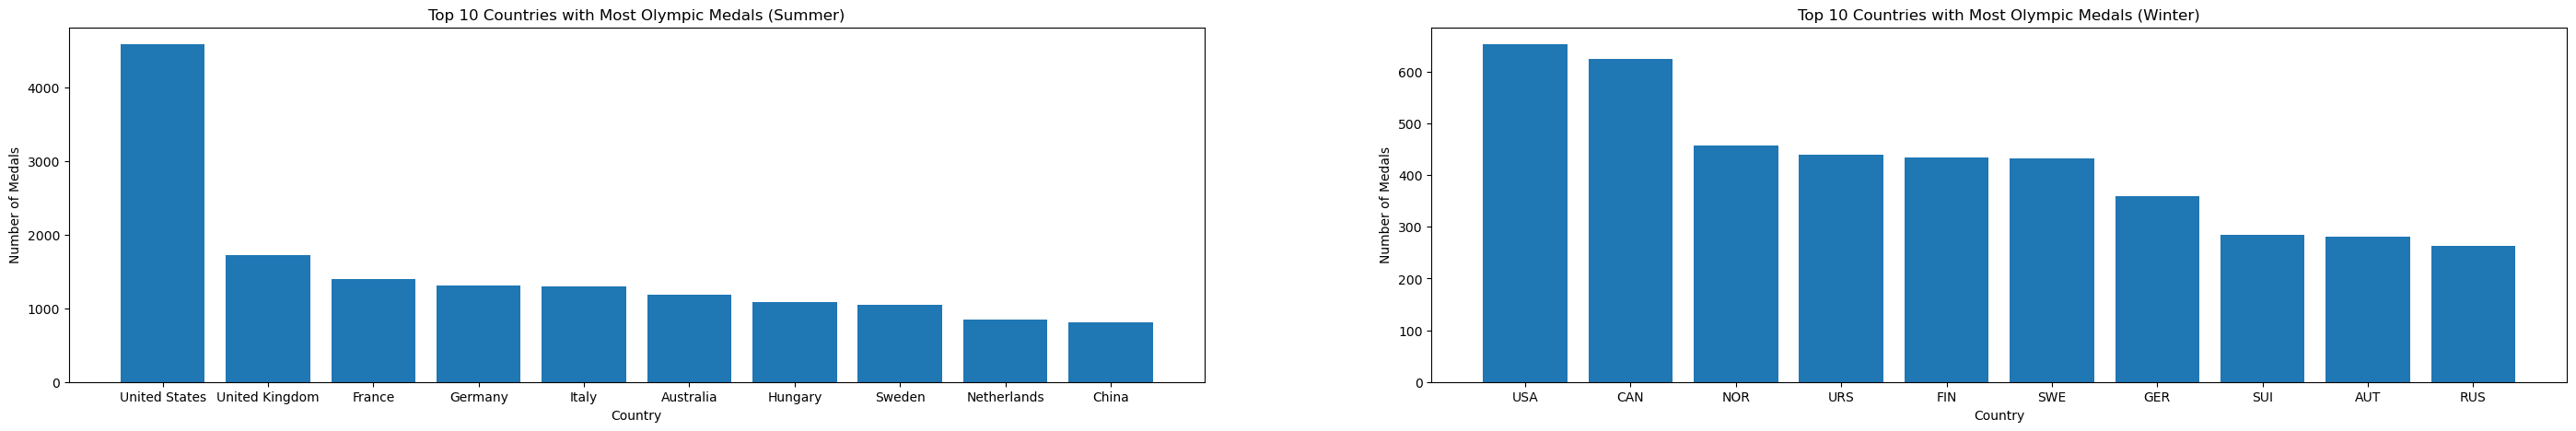

In [24]:
# Side by Side Bar Charts
fig, axs = plt.subplots(1, 2, figsize = (35, 5))

# Summer
axs[0].bar(medal_count_summer.index, medal_count_summer.values)
axs[0].set_xlabel("Country")
axs[0].set_ylabel("Number of Medals")
axs[0].set_title("Top 10 Countries with Most Olympic Medals (Summer)")

# Winter
axs[1].bar(medal_count_winter.index, medal_count_winter.values)
axs[1].set_xlabel("Country")
axs[1].set_ylabel("Number of Medals")
axs[1].set_title("Top 10 Countries with Most Olympic Medals (Winter)")

### EDA of Top 5 Medal Countries Changes Over Time (Summer vs Winter)

In [25]:
# Summer
top_5_summer = (clean_summer.groupby("Country").size().sort_values(ascending = False).head(5))
top_5_summer

Country
United States     4585
United Kingdom    1720
France            1396
Germany           1305
Italy             1296
dtype: int64

In [26]:
top_5_countries_over_time_summer = clean_summer[clean_summer["Country"].isin(top_5_summer.index)].groupby(["Year", "Country"]).size().unstack(fill_value = 0)
top_5_countries_over_time_summer

Country,France,Germany,Italy,United Kingdom,United States
Year,,,,,
1896,11,33,0,7,20
1900,185,40,4,78,55
1904,0,13,0,2,394
1908,35,22,7,347,63
1912,25,52,21,160,101
1920,141,0,84,107,193
1924,122,0,51,66,198
1928,36,72,70,55,84
1932,37,38,77,34,181


In [27]:
# Winter
top_5_winter = (clean_winter.groupby("Country").size().sort_values(ascending = False).head(5))
top_5_winter

Country
USA    653
CAN    625
NOR    457
URS    440
FIN    434
dtype: int64

In [28]:
top_5_countries_over_time_winter = clean_winter[clean_winter["Country"].isin(top_5_winter.index)].groupby(["Year", "Country"]).size().unstack(fill_value = 0)
top_5_countries_over_time_winter

Country,CAN,FIN,NOR,URS,USA
Year,,,,,
1924,9,15,17,0,13
1928,12,4,15,0,14
1932,20,3,10,0,45
1936,13,9,18,0,16
1948,20,9,13,0,16
1952,17,12,19,0,30
1956,20,12,4,37,26
1960,21,13,9,42,27
1964,7,15,15,46,8


Text(0.5, 1.0, 'Top 5 Countries with Most Olympic Medals Over Time (Winter)')

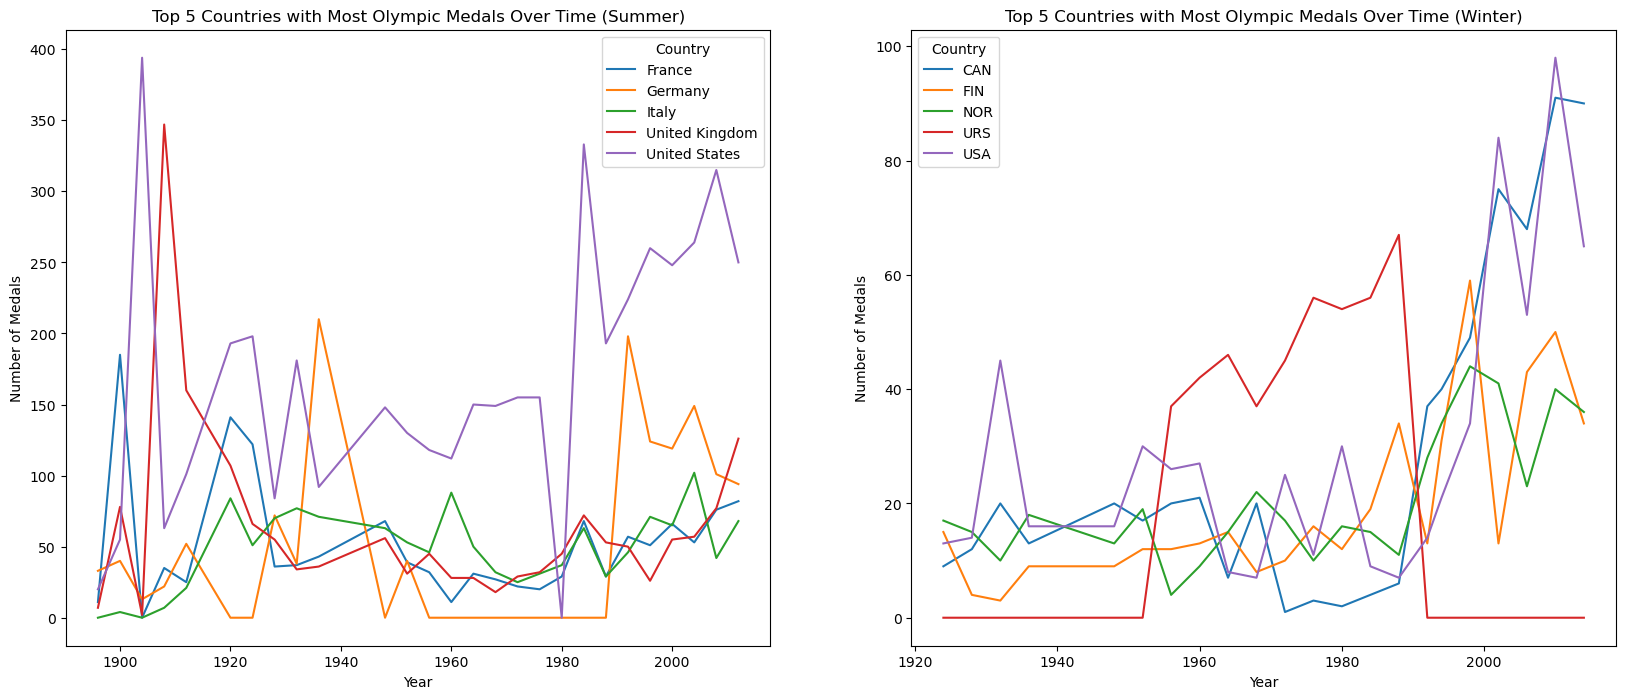

In [29]:
# Side by Side Line Graphs
fig, axes = plt.subplots(1, 2, figsize = (20, 8))

# Summer
top_5_countries_over_time_summer.plot(ax = axes[0])
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of Medals")
axes[0].set_title("Top 5 Countries with Most Olympic Medals Over Time (Summer)")

# Winter
top_5_countries_over_time_winter.plot(ax = axes[1])
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of Medals")
axes[1].set_title("Top 5 Countries with Most Olympic Medals Over Time (Winter)")

### EDA of Total Medal Counts by Gender Over Time (Summer vs Winter)

In [30]:
# Summer
gender_medal_summer = (clean_summer.groupby(["Year", "Gender"]).size().unstack())
gender_medal_summer

Gender,Men,Women
Year,,
1896,145.0,NaN
1900,469.0,7.0
1904,450.0,12.0
1908,762.0,15.0
1912,833.0,28.0
1920,1246.0,42.0
1924,798.0,51.0
1928,587.0,95.0
1932,551.0,60.0


In [31]:
# Winter
gender_medal_winter = (clean_winter.groupby(["Year", "Gender"]).size().unstack())
gender_medal_winter

Gender,Men,Women
Year,,
1924,112,6
1928,83,6
1932,110,6
1936,99,9
1948,125,15
1952,118,18
1956,123,27
1960,108,39
1964,139,46


Text(0.5, 1.0, 'Medal Counts by Gender Over Time (Winter)')

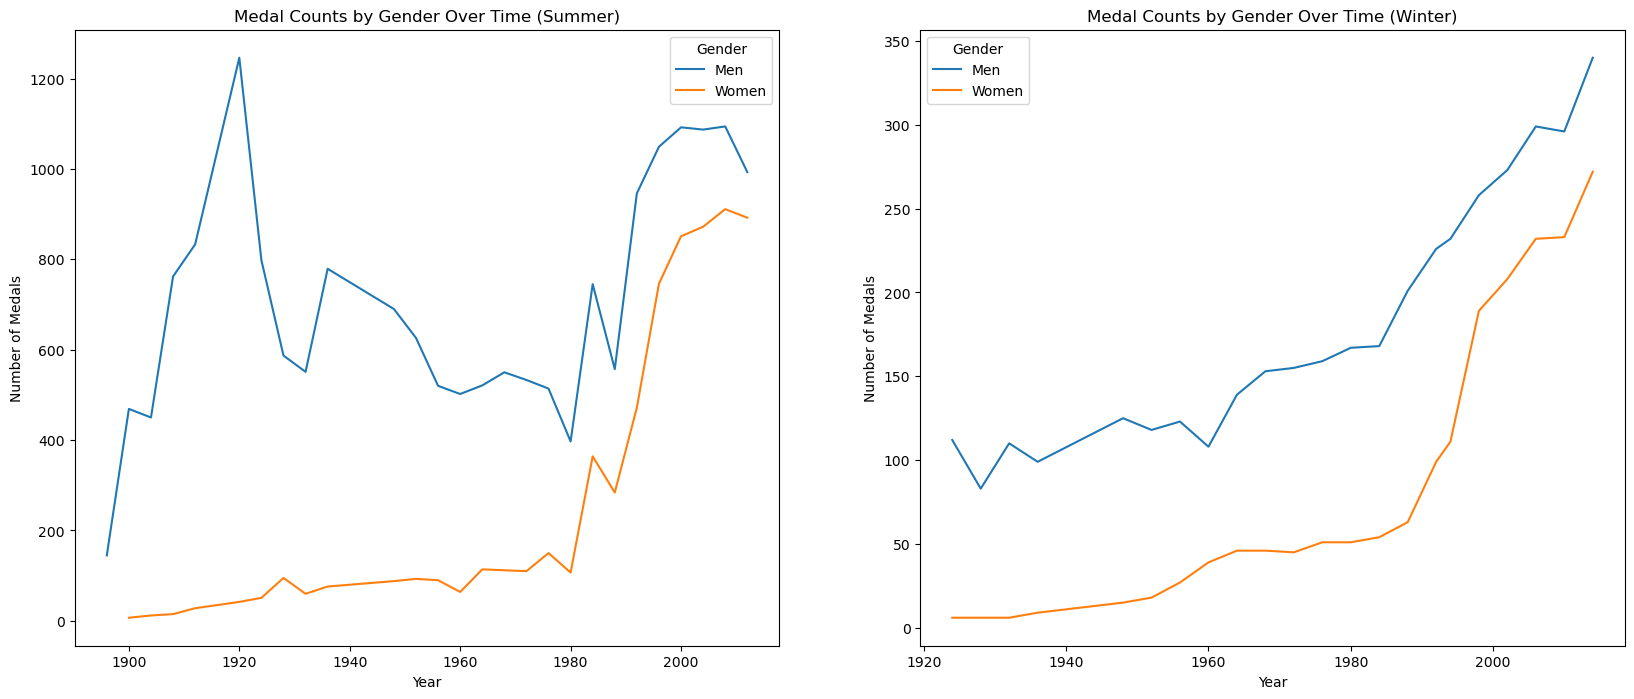

In [32]:
# Side by Side Line Graph
fig, axes = plt.subplots(1, 2, figsize = (20, 8))

# Summer
gender_medal_summer.plot(ax = axes[0])
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of Medals")
axes[0].set_title("Medal Counts by Gender Over Time (Summer)")

# Winter
gender_medal_winter.plot(ax = axes[1])
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of Medals")
axes[1].set_title("Medal Counts by Gender Over Time (Winter)")

## EDA of Total Medal Counts by Gender (Summer & Winter)

In [33]:
# Summer
gender_total_summer = clean_summer["Gender"].value_counts()
gender_total_summer

Gender
Men      19036
Women     6706
Name: count, dtype: int64

In [34]:
# Winter
gender_total_winter = clean_winter["Gender"].value_counts()
gender_total_winter

Gender
Men      3944
Women    1826
Name: count, dtype: int64

Text(0.5, 1.0, 'Total Medal Counts by Gender (Winter)')

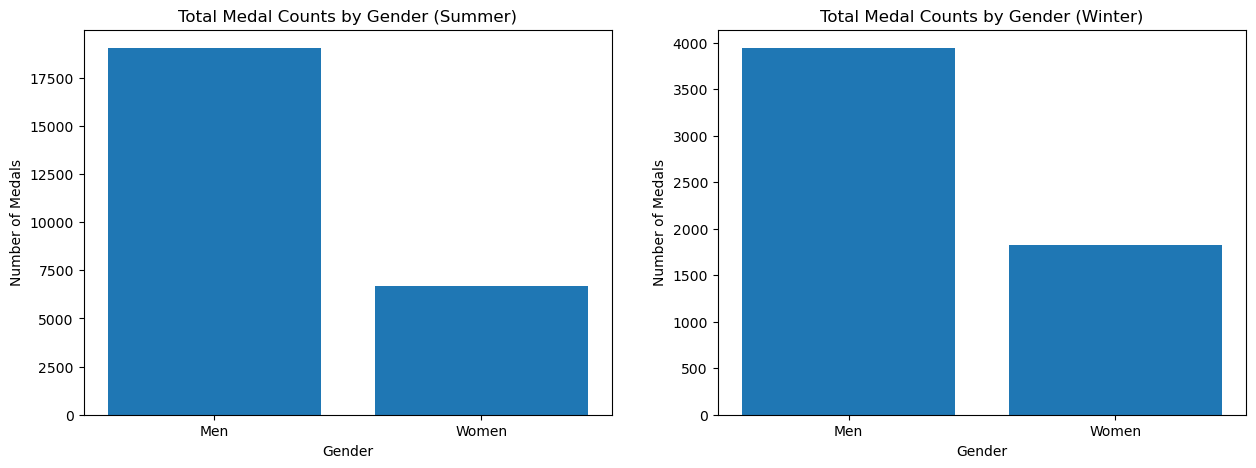

In [35]:
# Side by Side Bar Charts
fig, axs = plt.subplots(1, 2, figsize = (15, 5))

# Summer
axs[0].bar(gender_total_summer.index, gender_total_summer.values)
axs[0].set_xlabel("Gender")
axs[0].set_ylabel("Number of Medals")
axs[0].set_title("Total Medal Counts by Gender (Summer)")

# Winter
axs[1].bar(gender_total_winter.index, gender_total_winter.values)
axs[1].set_xlabel("Gender")
axs[1].set_ylabel("Number of Medals")
axs[1].set_title("Total Medal Counts by Gender (Winter)")

## Gender Representation in Medal Outcomes for both Summer and Winter Olympic Games

##### Summer Olympic Games Gender and Medal Outcome Analysis:

To begin this analysis, we first split up of data for each game by gender to be able to create visualizations for each and later on obtain medal counts for each gender separately.

In [36]:
summer_male_olympians = summer[summer['Gender'] == 'Men']
summer_female_olympians = summer[summer['Gender'] == 'Women']


In [37]:
Summer_Male_Olympians = summer_male_olympians.sort_values(by='Year', ascending=False).head(1000)
Summer_Male_Olympians

,Unnamed: 0,Year,City,Sport,Discipline,Athlete,Code,Gender,Event,Medal,Country
31164,31164,2012,London,Wrestling,Wrestling Freestyle,Jimmy Lidberg,SWE,Men,Wg 96 KG,Bronze,Sweden
29761,29761,2012,London,Athletics,Athletics,David Storl,GER,Men,Shot Put,Silver,Germany
29921,29921,2012,London,Canoe,Canoe Slalom,Sideris Tasiadis,GER,Men,C-1 (Single),Silver,Germany
29920,29920,2012,London,Canoe,Canoe Slalom,Tony Estanguet,FRA,Men,C-1 (Single),Gold,France
29919,29919,2012,London,Boxing,Boxing,Tervel Pulev,BUL,Men,81 - 91KG,Bronze,Bulgaria
...,...,...,...,...,...,...,...,...,...,...,...
30500,30500,2012,London,Hockey,Hockey,Marcel Balkestein,NED,Men,Hockey,Silver,Netherlands
30585,30585,2012,London,Judo,Judo,Felipe Kitadai,BRA,Men,- 60 KG,Bronze,Brazil
30527,30527,2012,London,Hockey,Hockey,Edward Ockenden,AUS,Men,Hockey,Bronze,Australia
30608,30608,2012,London,Judo,Judo,Miklos Ungvari,HUN,Men,60 - 66KG,Silver,Hungary


In [38]:
Summer_Female_Olympians = summer_female_olympians.sort_values(by='Year', ascending=False).head(1000)
Summer_Female_Olympians


,Unnamed: 0,Year,City,Sport,Discipline,Athlete,Code,Gender,Event,Medal,Country
31124,31124,2012,London,Wrestling,Wrestling Freestyle,Maider Unda,ESP,Women,Wf 72 KG,Bronze,Spain
29841,29841,2012,London,Basketball,Basketball,Candace Parker,USA,Women,Basketball,Gold,United States
29839,29839,2012,London,Basketball,Basketball,Angel Mccoughtry,USA,Women,Basketball,Gold,United States
29838,29838,2012,London,Basketball,Basketball,Asjha Jones,USA,Women,Basketball,Gold,United States
29837,29837,2012,London,Basketball,Basketball,Sylvia Fowles,USA,Women,Basketball,Gold,United States
...,...,...,...,...,...,...,...,...,...,...,...
27642,27642,2008,Beijing,Athletics,Athletics,Mary Wineberg,USA,Women,4X400M Relay,Gold,United States
27640,27640,2008,Beijing,Athletics,Athletics,Monique Henderson,USA,Women,4X400M Relay,Gold,United States
27731,27731,2008,Beijing,Badminton,Badminton,Yili Wei,CHN,Women,Doubles,Bronze,China
27639,27639,2008,Beijing,Athletics,Athletics,Allyson Felix,USA,Women,4X400M Relay,Gold,United States


After exploring the variables by genders in the more recent Summer Olypic games, we decided that to explore the amount of Olympic Medals obtained and to compare them between genders, we will also organize our data using the 'Discipline' variable which how each sport type is categorized.

For this we will get the medal count for the top 5 sports within the datasets for each of the games and these sports will be the same for both gender so we will be able to compare if one gender performs better over the other based on the Olympic Disciplines or perhaps the Olympic season as well.

In [39]:
Summer_Male_Olympians = summer_male_olympians.sort_values(by='Year', ascending=False).head(15)
Summer_Male_Olympians

#This will help us see how many female atheletes there are in each discipline for the summer olympics
summer_male_olympians.groupby('Discipline').size()

#nthis will help us see  which ones have medals won
summer_male_olympians.groupby('Medal').size()

#this will now let us combine the two above so the number of female metals per each disicipline for the summer olympics
Summer_Male_Olympians_Medals_by_Discipline = summer_male_olympians.groupby(['Discipline', 'Medal']).size().head(21)
Summer_Male_Olympians_Medals_by_Discipline

Discipline   Medal 
Archery      Bronze     55
             Gold       87
             Silver     76
Artistic G.  Bronze    447
             Gold      536
             Silver    477
Athletics    Bronze    818
             Gold      826
             Silver    831
BMX          Bronze      1
             Gold        1
             Silver      1
Badminton    Bronze     26
             Gold       23
             Silver     23
Baseball     Bronze    112
             Gold      111
             Silver    112
Basketball   Bronze    215
             Gold      222
             Silver    216
dtype: int64

In [40]:
#This will help us see how many female atheletes there are in each discipline for the summer olympics
summer_female_olympians.groupby('Discipline').size()

#nthis will help us see  which ones have medals won
summer_female_olympians.groupby('Medal').size()

#this will now let us combine the two above so the number of female metals per each disicipline for the summer olympics
Summer_Female_Olympians_Medals_by_Discipline = summer_female_olympians.groupby(['Discipline', 'Medal']).size().head(21)

Summer_Female_Olympians_Medals_by_Discipline

Discipline        Medal 
Archery           Bronze     35
                  Gold       39
                  Silver     37
Artistic G.       Bronze    216
                  Gold      216
                  Silver    211
Athletics         Bronze    381
                  Gold      389
                  Silver    393
BMX               Bronze      1
                  Gold        1
                  Silver      1
Badminton         Bronze     26
                  Gold       23
                  Silver     23
Basketball        Bronze    119
                  Gold      120
                  Silver    120
Beach Volleyball  Bronze      2
                  Gold        2
                  Silver      2
dtype: int64

Below will follow the visualizations for the data in the previous code chunks.

C:\Users\kimca\AppData\Local\Temp\ipykernel_13292\3667344620.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Medal Type')


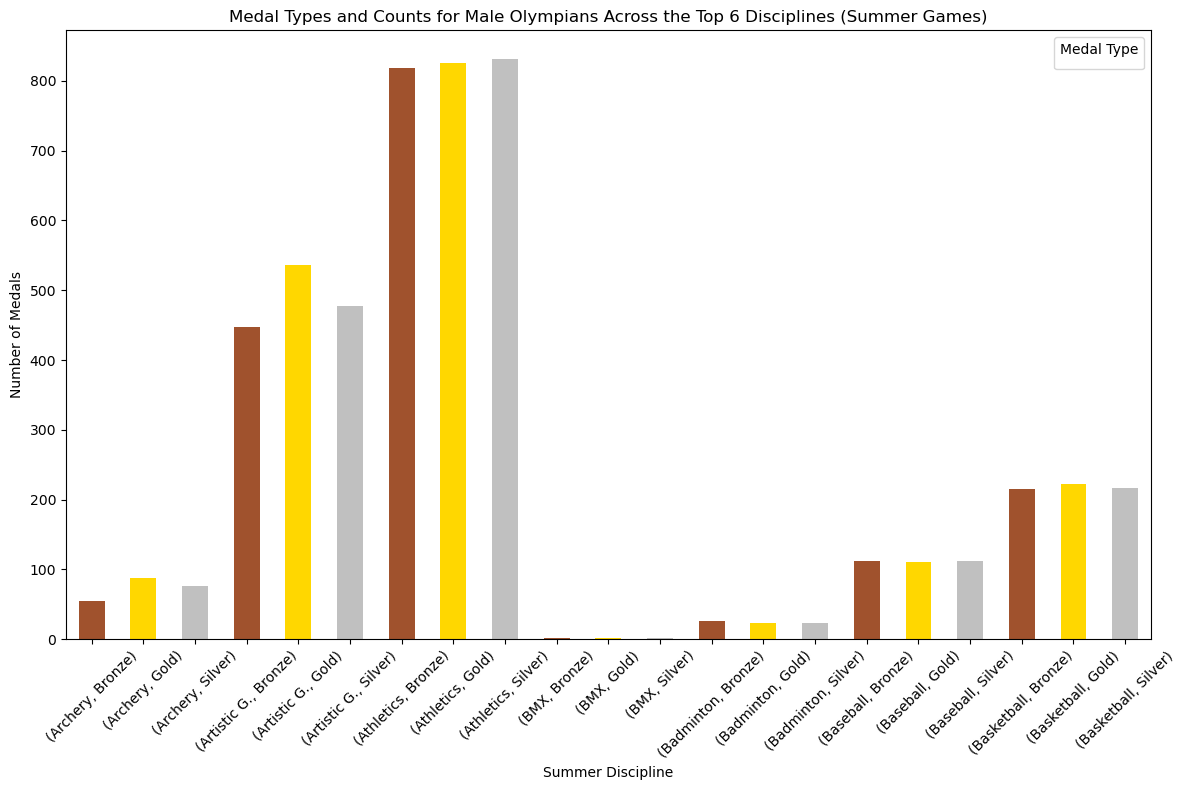

In [41]:
Summer_Male_Olympians_Medals_by_Discipline.plot(kind='bar', stacked=True, figsize=(12, 8), color=['sienna', 'gold', 'silver'])
plt.title('Medal Types and Counts for Male Olympians Across the Top 6 Disciplines (Summer Games)')
plt.xlabel('Summer Discipline')
plt.ylabel('Number of Medals')
plt.legend(title='Medal Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\kimca\AppData\Local\Temp\ipykernel_13292\2476536777.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Medal Type')


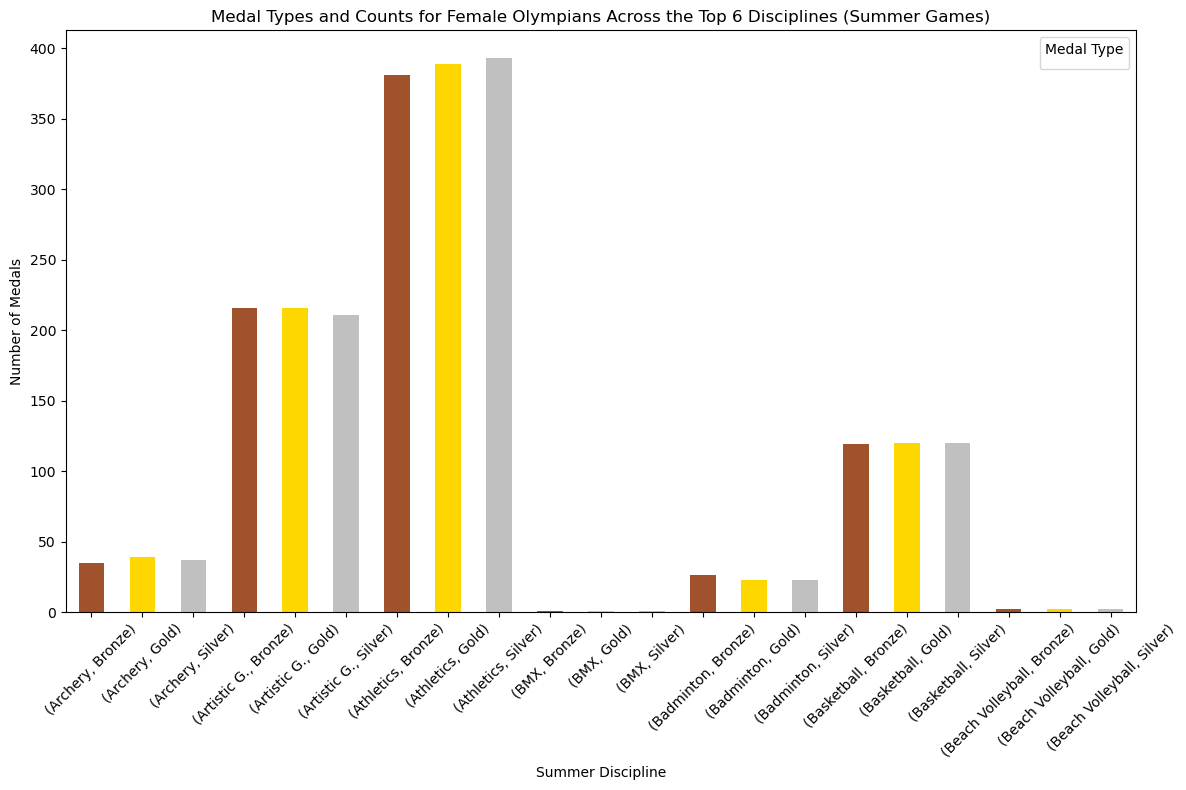

In [42]:
Summer_Female_Olympians_Medals_by_Discipline.plot(kind='bar', stacked=True, figsize=(12, 8), color=['sienna', 'gold', 'silver'])
plt.title('Medal Types and Counts for Female Olympians Across the Top 6 Disciplines (Summer Games)')
plt.xlabel('Summer Discipline')
plt.ylabel('Number of Medals')
plt.legend(title='Medal Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Analysis:

Based on visualizations of medal types and counts for male and female Olympians across the top six disciplines of the summer Olympic Games, we can conclude that Male Olympians have a higher overall medal count across these six disciplines. When creating these visuals, we use the same scale in both visualizations to try to keep it on the same medal count; however, despite these efforts, the medal type visualization created for medal Olympians is on a different scale, where the maximum of the Y axis is 800, versus the scale of the female Olympians medal types visitor realization is maximum is 400. So from this, we can already see that on average, for the top six disciplines in the Summer Olympic Games, male Olympians are on a scale that is double that of female Olympians when it comes to medal types and count awarded.

In this visualization, we are seeing the count for bronze, silver, and gold medals within the disciplines of archery, artistic, athletics, BMX, badminton, basketball, and beach volleyball. And so within these, the one that ranks highest in medal types for both males and females is going to be Artistic, which stands for artistic gymnastics, and so what we see is that for both male and female Olympians in the summer from these six disciplines, the highest medal count belongs to artistic gymnastics. The medal count for men is double that of the medal count for female Olympians, at almost 800. 


#### Winter Olympic Games Gender and Medal Outcome Analysis:

In [43]:
#now to split it up into the winter olympics and do the same thing as above

winter_male_olympians = winter[winter['Gender'] == 'Men']

winter_female_olympians = winter[winter['Gender'] == 'Women']

Winter_Male_Olympians_by_Year = winter_male_olympians.sort_values(by='Year', ascending=False).head(15)
Winter_Male_Olympians_by_Year

,Unnamed: 0,Year,City,Sport,Discipline,Athlete,Country,Gender,Event,Medal
5754,5754,2014,Sochi,Skiing,Snowboard,"DEIBOLD, Alex",USA,Men,Snowboard Cross,Bronze
5327,5327,2014,Sochi,Ice Hockey,Ice Hockey,"VATANEN, Sami",FIN,Men,Ice Hockey,Bronze
5319,5319,2014,Sochi,Ice Hockey,Ice Hockey,"PIHLSTROM, Antti",FIN,Men,Ice Hockey,Bronze
5320,5320,2014,Sochi,Ice Hockey,Ice Hockey,"RASK, Tuukka",FIN,Men,Ice Hockey,Bronze
5321,5321,2014,Sochi,Ice Hockey,Ice Hockey,"RUUTU, Tuomo",FIN,Men,Ice Hockey,Bronze
5322,5322,2014,Sochi,Ice Hockey,Ice Hockey,"SALMINEN, Sakari",FIN,Men,Ice Hockey,Bronze
5323,5323,2014,Sochi,Ice Hockey,Ice Hockey,"SALO, Sami",FIN,Men,Ice Hockey,Bronze
5324,5324,2014,Sochi,Ice Hockey,Ice Hockey,"SELANNE, Teemu",FIN,Men,Ice Hockey,Bronze
5325,5325,2014,Sochi,Ice Hockey,Ice Hockey,"TIMONEN, Kimmo",FIN,Men,Ice Hockey,Bronze
5326,5326,2014,Sochi,Ice Hockey,Ice Hockey,"VAANANEN, Ossi",FIN,Men,Ice Hockey,Bronze


In [44]:
winter_male_olympians.sort_values(by='Year', ascending=False).head(15)

#This will help us see how many male atheletes there are in each discipline for the winter olympics
winter_male_olympians.groupby('Discipline').size()

#nthis will help us see  which ones have medals won
winter_male_olympians.groupby('Medal').size()

#this will now let us combine the two above so the number of female metals per each disicipline for the winter olympics
Winter_Male_Olympian_Medals_By_Discipline = winter_male_olympians.groupby(['Discipline', 'Medal']).size().head(21)
Winter_Male_Olympian_Medals_By_Discipline

Discipline            Medal 
Alpine Skiing         Bronze     72
                      Gold       71
                      Silver     72
Biathlon              Bronze     89
                      Gold       90
                      Silver     91
Bobsleigh             Bronze    139
                      Gold      126
                      Silver    133
Cross Country Skiing  Bronze    150
                      Gold      151
                      Silver    149
Curling               Bronze     31
                      Gold       33
                      Silver     33
Figure skating        Bronze     59
                      Gold       61
                      Silver     60
Freestyle Skiing      Bronze     17
                      Gold       17
                      Silver     17
dtype: int64

C:\Users\kimca\AppData\Local\Temp\ipykernel_13292\2187495393.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Medal Type')


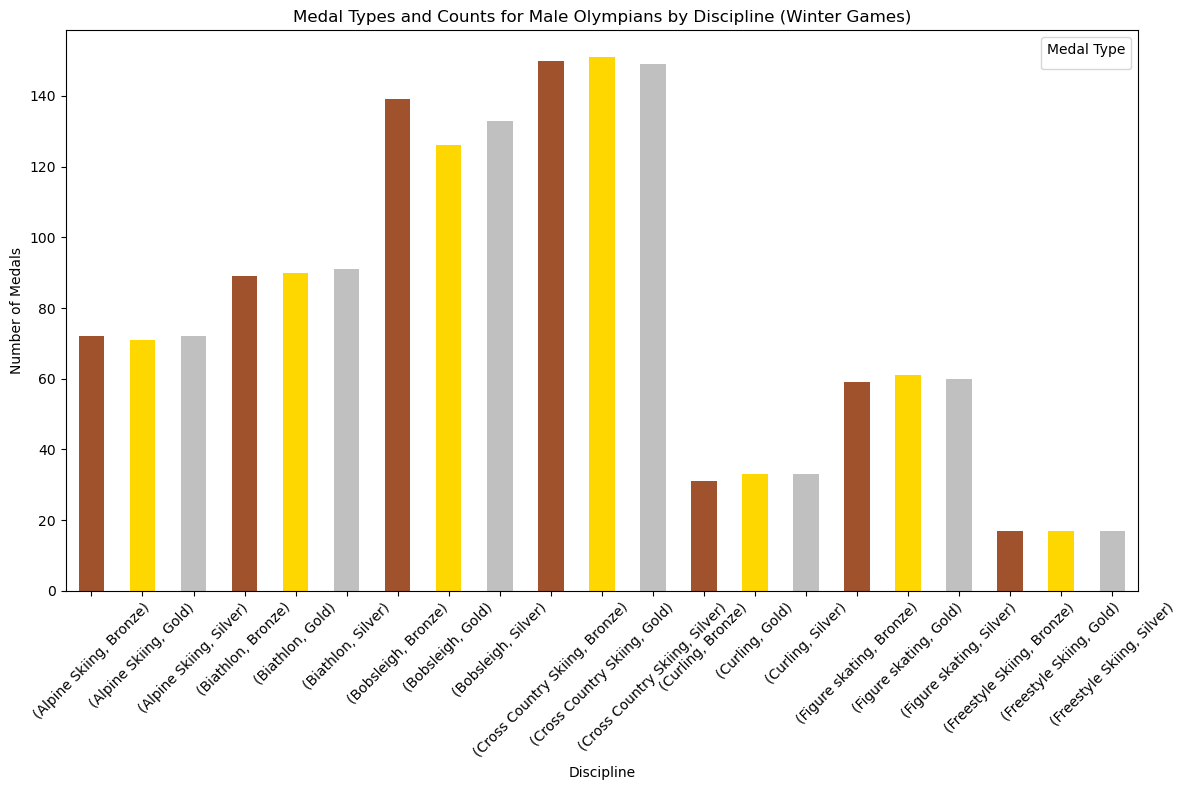

In [45]:
Winter_Male_Olympian_Medals_By_Discipline.plot(kind='bar', stacked=True, figsize=(12, 8), color=['sienna', 'gold', 'silver'])
plt.title('Medal Types and Counts for Male Olympians by Discipline (Winter Games)')
plt.xlabel('Discipline')
plt.ylabel('Number of Medals')
plt.legend(title='Medal Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [46]:
winter_female_olympians.sort_values(by='Year', ascending=False).head(15)

#This will help us see how many female atheletes there are in each discipline for the winter olympics
winter_female_olympians.groupby('Discipline').size()

#nthis will help us see  which ones have medals won
winter_female_olympians.groupby('Medal').size()

#this will now let us combine the two above so the number of female metals per each disicipline for the winter olympics

Winter_Female_Olympian_Medals_By_Discipline = winter_female_olympians.groupby(['Discipline', 'Medal']).size().head(21)
Winter_Female_Olympian_Medals_By_Discipline

Discipline            Medal 
Alpine Skiing         Bronze     69
                      Gold       72
                      Silver     72
Biathlon              Bronze     50
                      Gold       50
                      Silver     50
Bobsleigh             Bronze      8
                      Gold        8
                      Silver      8
Cross Country Skiing  Bronze    113
                      Gold      113
                      Silver    113
Curling               Bronze     25
                      Gold       25
                      Silver     25
Figure skating        Bronze     59
                      Gold       61
                      Silver     59
Freestyle Skiing      Bronze     17
                      Gold       17
                      Silver     17
dtype: int64

C:\Users\kimca\AppData\Local\Temp\ipykernel_13292\589875797.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Medal Type')


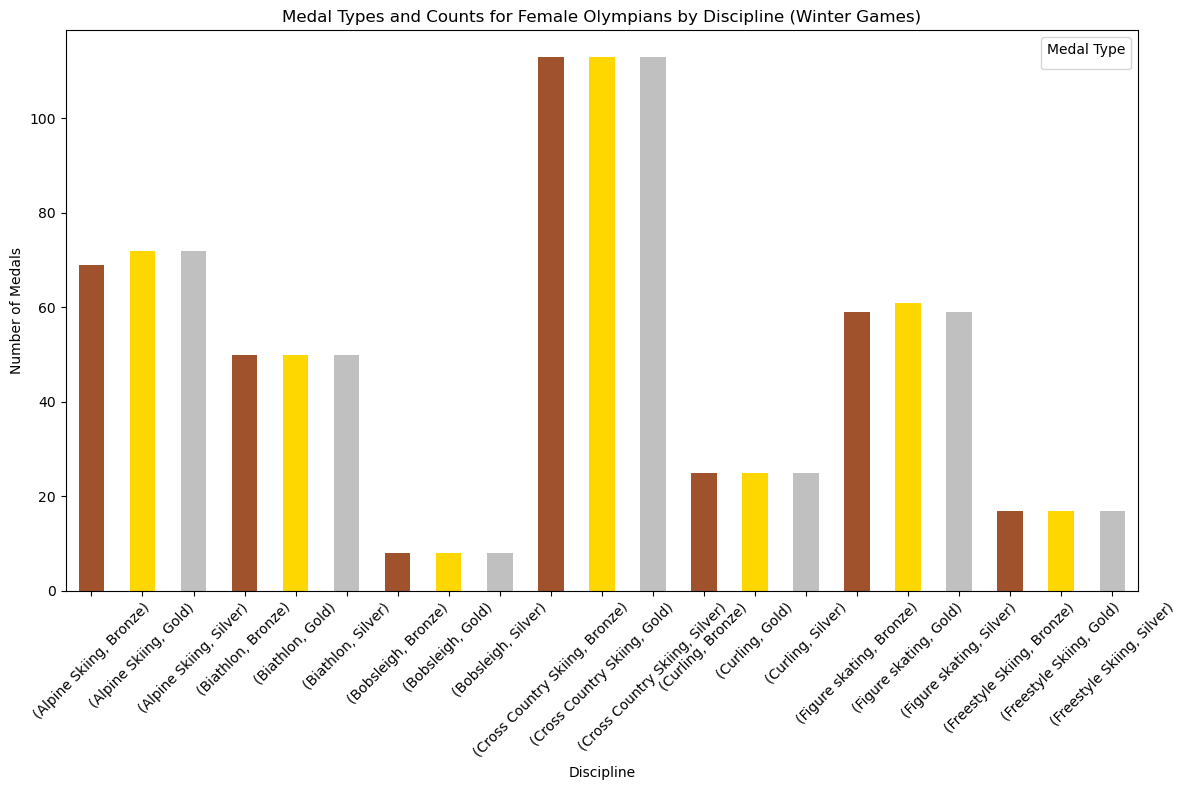

In [ ]:
Winter_Female_Olympian_Medals_By_Discipline.plot(kind='bar', stacked=True, figsize=(12, 8), color=['sienna', 'gold', 'silver'])
plt.title('Medal Types and Counts for Female Olympians by Discipline (Winter Games)')
plt.xlabel('Discipline')
plt.ylabel('Number of Medals')
plt.legend(title='Medal Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
Analysis of Visual: 


Analysis of Visual:


For the Winter Olympic Games medal count visualizations on gender, the disciplines that are being analyzed for the Bronze, Silver, or Gold medals are Alpine skiing, Biathlon, Bobsleigh, Cross-Country Skiing, Curling, Figure Skating, and Freestyle Skiing. Similar to how the scale was different for the Summer Olympic Games, the scale is higher on the male Olympians visualization, but the gap in scale between the two visualizations is very minimal compared to that of the Summer Olympic Games. This tells us that Male and Female Olympians are on a similar scale when it comes to medal types awarded across their disciplines. 

One of the results that stands out the most is the results for the Bobsleigh count from Male Olympians versus Female Olympians. This stands out the most because the medal count awarded across Bronze, Silver, and Gold for Female Olympians is at about 10 medals for each of those three, but for the Male Olympians, their average number of medals awarded for Bob Sleigh is about 140 for Bronze, about 125 for Gold, and about 130 for Silver. Despite the major difference in Bobsleigh, across the other five disciplines, male and female Olympians hold very similar medal counts awarded, and are on the same scale for sports such as Figure Skating and Alpine Skiing.
